In [73]:
from typing import TypedDict, List, Annotated, Optional
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
from huggingface_hub import InferenceClient
from exa_py import Exa
from langgraph.types import Send
import os
import json
from operator import add
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from IPython.display import Image, display
from db.database import SessionLocal, init_db
from db.crud import create_track, save_syllabus
import re
load_dotenv()
init_db()


In [321]:
llm=ChatGroq(model_name="llama-3.3-70b-versatile", api_key=os.getenv('GROQ_API'))


In [77]:
llm.invoke("what is your name").content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

In [21]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
response = tavily_client.search("tell me about mutual funds", include_answer=True)
response['answer']


'A mutual fund pools money from many investors to buy securities like stocks and bonds. It allows individuals to invest collectively and diversify their portfolios. Mutual funds are managed by professionals to maximize returns.'

In [22]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "blog post about artificial intelligence",
  type="auto",
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [23]:
print(result)

Title: Artificial Intelligence Blog: AI Blog
URL: https://www.artificial-intelligence.blog/
ID: https://www.artificial-intelligence.blog/
Score: None
Published Date: None
Author: None
Image: http://static1.squarespace.com/static/62ec2bc76a27db7b37a2b32f/t/68974039b71d0f1a6f3e6920/1754742841664/of+ai-blog-youtube-2025.png?format=1500w
Favicon: https://images.squarespace-cdn.com/content/v1/62ec2bc76a27db7b37a2b32f/abfb4587-35b3-411f-8603-7e24344b95fc/favicon.ico?format=100w
Extras: None
Subpages: None
Text: None
Summary: None
Highlights: [' this website as a form of digital art, as all images and text were generated by artificial intelligence(with a little bit of human help). ## AI Blog Posts & AI News\n\n3 Actionable AI Recommendations for Businesses in 2026 education, business, technology In 2026, AI advantage will not come from tools but from focus. This piece outlines three concrete, disruptive moves businesses can make to turn AI into durable leverage, plus the contrarian and pessim

In [24]:
class SyllabusItem(BaseModel):
    day: int = Field(description="Day number in the syllabus")
    title: str = Field(description="Title for the day")
    concepts: List[str] = Field(
        description="2 to 4 concepts introduced on this day"
    )
class AgentState(TypedDict):
    topic: str
    total_days: int
    syllabus: list[SyllabusItem]  # [{day, title, goal, concepts}]
    revision_count: int = 0     # tracks retry loops
    quality_score: float = 0.0,
    track_id: int

class SyllabusOutput(BaseModel):
    syllabus: List[SyllabusItem]
    
class DaysDecision(BaseModel):
    total_days: int = Field(ge=3, le=14, description="Number of days needed to cover this topic well for a beginner")
    reasoning:  str = Field(description="One sentence explaining why this many days")


In [25]:

def parse_input(state: AgentState) -> dict:
    """
    Sanitise topic, then let the LLM decide the optimal number of days
    based on the topic's breadth and complexity.
    Falls back to user-provided total_days if LLM call fails.
    """
    cleaned_topic = state['topic'].strip()
    
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    structured_llm = llm.with_structured_output(DaysDecision)

    try:
        decision: DaysDecision = structured_llm.invoke([
            SystemMessage(content="""You are a curriculum planner for a beginner learning newsletter.
Your job is to decide how many days a topic needs to be covered well — 
not too shallow, not overwhelming.

Guidelines:
- 3 days:  very focused, narrow topic (e.g. "what is a token", "how GPS works")
- 5 days:  clear single-domain topic (e.g. "how transformers work", "what is inflation")
- 7 days:  broader topic with multiple interconnected ideas (e.g. "how the internet works", "what is machine learning")
- 10 days: wide domain needing real depth (e.g. "the history of AI", "how financial markets work")
- 14 days: only for very broad domains a beginner needs significant time to absorb (e.g. "quantum computing", "evolutionary biology")

Always prefer fewer days. A tight 5-day arc beats a padded 10-day one."""),
            HumanMessage(content=f"""
Topic: "{cleaned_topic}"

How many days does this topic need for a complete beginner to genuinely understand it?
Stay between 3 and 14 days.
""")
        ])

        total_days = decision.total_days
        print(f"[parse_input] topic='{cleaned_topic}' → {total_days} days ({decision.reasoning})")

    except Exception as e:
        # Fall back to user-provided value, clamped to safe range
        total_days = max(3, min(14, state.get('total_days', 5)))
        print(f"[parse_input] LLM decision failed ({e}) — using {total_days} days")

    return {
        "topic":      cleaned_topic,
        "total_days": total_days,
    }

In [26]:
def generate_syllabus(state: AgentState) -> dict:
    structured_llm = llm.with_structured_output(SyllabusOutput)
    response: SyllabusOutput = structured_llm.invoke([
        SystemMessage(content="""You are an expert curriculum designer 
        specialising in beginner-friendly conceptual learning paths.
        You MUST return the response using the provided tool schema.
        The output must contain a field called `syllabus`.
        
        Your curriculum is purely theoretical — no setup, no coding, no tools.
        Every concept should be something the reader understands deeply,
        not something they do or install."""),
        HumanMessage(content=f"""
Design a {state['total_days']}-day conceptual learning curriculum for: "{state['topic']}"
Target level: complete beginner — no prior knowledge assumed

Rules:
1. Day 1 must explain what {state['topic']} is, where it came from, and why it matters
2. Each day must introduce exactly 3–4 concepts
3. Concepts must be ideas, mental models, or principles — never tasks or actions
4. Concepts must build logically from previous days
5. Day {state['total_days']} must synthesise everything — how the concepts connect and what the bigger picture looks like
6. Titles should spark curiosity, not sound like a course syllabus
7. Never include: installation, setup, coding, tools, frameworks, or hands-on tasks
""")
    ])

    print(f"[generate_syllabus] Generated {len(response.syllabus)} days")
    return {"syllabus": [s.model_dump() for s in response.syllabus]}

In [27]:
def save_to_db(state: AgentState) -> dict:
    """
    Creates a Track row and saves all SyllabusItems to SQLite.
    Returns track_id so downstream systems (Graph 2) can reference it.
    """
    db = SessionLocal()
    try:
        # Create the track
        track = create_track(
            db=db,
            topic=state["topic"],
            total_days=state["total_days"],
        )

        # Save every syllabus item
        save_syllabus(
            db=db,
            track_id=track.id,
            syllabus=state["syllabus"],   # already list[dict] from model_dump()
        )

        print(f"[save_to_db] Track {track.id} saved — {len(state['syllabus'])} days")
        return {"track_id": track.id}

    except Exception as e:
        db.rollback()
        print(f"[save_to_db] Failed: {e}")
        raise
    finally:
        db.close()

In [28]:
def build_curriculum_graph():
    g = StateGraph(AgentState)

    # nodes
    g.add_node("parse_input",       parse_input)
    g.add_node("generate_syllabus", generate_syllabus)
    g.add_node("save_to_db", save_to_db)

    # edges (connections)
    g.add_edge(START, "parse_input")
    g.add_edge("parse_input", "generate_syllabus")
    g.add_edge("generate_syllabus","save_to_db")
    g.add_edge("save_to_db",END)

    # Optionally, return or use the graph
    return g.compile()


In [29]:
curriculum_graph = build_curriculum_graph()

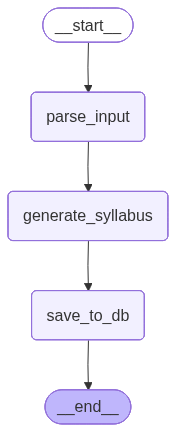

In [30]:
display(Image(curriculum_graph.get_graph().draw_mermaid_png()))

In [31]:
test_state = {
    "topic": "Machine Learning",
    "total_days": 1,
    "syllabus": []}

result = curriculum_graph.invoke(test_state)
print(result)

[parse_input] topic='Machine Learning' → 7 days (Machine learning is a broader topic with multiple interconnected ideas, such as supervised and unsupervised learning, neural networks, and deep learning, which can be covered in 7 days.)


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01j8g1njfaft9bwzpgra60m4xh` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99649, Requested 524. Please try again in 2m29.472s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

MAKING THE SECOND GRAPH

In [228]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "Unlocking the Power of Claude 4.6: What's the Big Deal?",
  type="auto",
  num_results=10,
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [229]:
result

SearchResponse(results=[Result(url='https://www.anthropic.com/news/claude-opus-4-6', id='https://www.anthropic.com/news/claude-opus-4-6', title='Introducing Claude Opus 4.6', score=None, published_date=None, author=None, image='https://cdn.sanity.io/images/4zrzovbb/website/01d06528567e4bd22c3ddedc87f609ee5716a009-2400x1260.png', favicon='https://www.anthropic.com/favicon.ico', subpages=None, extras=None, entities=None, text=None, summary=None, highlights=[" It plans more carefully, sustains agentic tasks for longer, can operate more reliably in larger codebases, and has better code review and debugging skills to catch its own mistakes. And, in a first for our Opus-class models, Opus 4.6 features a 1M token context window in beta1. Opus 4.6 can also apply its improved abilities to a range of everyday work tasks: running financial analyses, doing  ...    can multitask autonomously, Opus 4.6 can put all these skills to work on your behalf. The model’s performance is state-of-the-art on se

In [355]:
from typing import List
from pydantic import BaseModel


class SyllabusItem(BaseModel):
    day: int
    title: str
    concepts: List[str]

class ConceptBrief(BaseModel):
    concept: str
    definition: str      # 1 sentence — what it is
    example: str         # 1 concrete real world example
    fun_fact: str        # 1 surprising or interesting fact
    best_url: str        # single best link for further reading

class ExaResult(BaseModel):
    url: str
    title: str
    snippet: str
    summary: str


class Section(BaseModel):
    concept: str
    heading: str
    key_points: List[str]
    exa_queries: List[str]        # max 2, Exa fires these
    target_words:int=500


class Plan(BaseModel):
    newsletter_title: str
    hook: str
    tone: str
    sections: List[Section]
    takeaway: str

class ContentState(TypedDict):
    item: SyllabusItem
    plan: Plan | None = None
    research: List[ExaResult] = []
    research_summary: list[ConceptBrief]
    draft: str = ""
    feedback: str = ""
    revision_count: int = 0
    approved: bool = False
    newsletter: str = ""

In [356]:
def planner_node(state: ContentState) -> dict:
    PLANNER_PROMPT = """
You are creating the outline for a modern tech newsletter lesson.

The writing style should feel like popular tech newsletters such as TLDR, The Neuron, or AI Brew: smart, conversational, and easy to skim.

The reader should feel like they learned something useful in under 60 seconds.

Your job is NOT to write the full article. Your job is to produce a structured PLAN that a writer will expand into the final newsletter section.

--------------------------------------------------

INPUTS

Day: {day}
Topic Title: {title}
Concepts: {concepts}

--------------------------------------------------

TASK

Create a structured plan for a newsletter lesson.

--------------------------------------------------

INSTRUCTIONS

1. NEWSLETTER TITLE

Write a catchy newsletter-style title.

The title should:
- spark curiosity
- feel modern
- avoid textbook wording

Examples:
"Neural Networks: The Brains Behind Modern AI"
"The 3 Building Blocks Powering Every AI System"

--------------------------------------------------

2. HOOK (2–3 sentences)

Write a short opening hook that grabs attention.

The hook should:
- introduce the topic quickly
- create curiosity
- explain why the reader should care

Example tone:

"Every AI system you hear about — from ChatGPT to self-driving cars — runs on the same core idea: neural networks.

But the strange part? These powerful systems are built from extremely simple mathematical units.

Today we'll break down the three building blocks that make it all work."

--------------------------------------------------

3. SECTIONS

For EACH concept create a section containing:

heading  
An engaging section title.

Avoid generic titles like:
"Introduction to..."

Examples:
"Meet the Tiny Neurons Running the Show"
"Stacking Layers to Build Intelligence"

key_points

Write 3–5 bullet ideas explaining HOW the concept works.

Rules:
- explain the mechanism
- avoid vague statements
- focus on intuition
- keep sentences short

Bad example:
"Neurons process data"

Good example:
"A neuron takes numbers as input and multiplies them by learned weights."

exa_queries

Provide up to 2 search queries that would help find:
- examples
- case studies
- explanations
NOTE - that since exa is scemantic, the queries should be best designed for learning purposes.

Queries should be specific and useful.

--------------------------------------------------

4. STYLE GUIDELINES

The final article should feel:

• clear  
• engaging  
• beginner friendly  
• easy to skim  

Use:
- short sentences
- concrete explanations
- intuitive mental models

Avoid:
- academic language
- textbook definitions
- vague bullet points

--------------------------------------------------

5. TAKEAWAY

End with one memorable sentence capturing the big idea.

Example:

"Big idea: neural networks turn simple math operations into powerful pattern-recognition machines."

--------------------------------------------------

OUTPUT REQUIREMENTS

Return ONLY valid JSON matching the Plan schema.

Important rules:

- "sections" MUST be a JSON array
- Do NOT wrap arrays or objects as strings
- Do NOT include markdown
- Do NOT include explanations
- Do NOT include text outside the JSON

...
Return a valid Plan object with these exact fields:
- newsletter_title (not 'name', not 'title')
- hook
- tone
- sections
- takeaway
...
"""

    prompt = PLANNER_PROMPT.format(
        day=state['item']['day'],
        title=state['item']['title'],
        concepts=", ".join(state['item']['concepts']),
    )
    llm=ChatGroq(model_name="llama-3.3-70b-versatile", api_key=os.getenv('GROQ_API_KEY'))
    plan = llm.with_structured_output(Plan).invoke(prompt)

    return {"plan": plan}

In [357]:
def research_node(state: ContentState) -> dict:
    """Based on the exa queries defined in the planner node, the exa search will be triggered"""
    
    exa_queries_list = []
    for section in state['plan'].sections:
        for query in section.exa_queries:
            exa_queries_list.append(query)
    
    print(f"\n{'='*60}")
    print(f"🔍 RESEARCHER NODE")
    print(f"{'='*60}")
    print(f"📋 Total queries to run: {len(exa_queries_list)}")
    for i, q in enumerate(exa_queries_list, 1):
        print(f"   {i}. {q}")

    query_results = []
    seen_urls = set()
    for query in exa_queries_list:
        print(f"\n🔎 Searching: '{query}'")
        result = exa.search(
            query,
            type="auto",
            num_results=2,
            contents={
                "highlights": {
                    "max_characters": 4000
                },"text":True, 'summary': True
            },
            include_domains=[
            "developers.google.com",
            "coursera.org", 
            "arxiv.org",
            "datacamp.com",
            "baeldung.com",
            "wikipedia.org",
            "towardsdatascience.com"
        ]
        )
        for item in result.results:
            if item.url in seen_urls:
                continue

            seen_urls.add(item.url)
            exa_result = ExaResult(
                url=item.url,
                title=item.title,
                summary=item.summary if item.summary else "",
                snippet=item.highlights[0] if item.highlights else ""
            )
            query_results.append(exa_result)
            print(f"   ✅ {item.title}")
            print(f"      🔗 {item.url}")
            print(f"      📝 {exa_result.snippet[:100]}...")

    print(f"\n{'='*60}")
    print(f"✅ Research complete — {len(query_results)} results collected")
    print(f"{'='*60}\n")

    return {"research": query_results}

In [358]:
def summarizer_node(state: ContentState) -> dict:
    SUMMARIZER_PROMPT = """
        You are a research distiller for a beginner-friendly learning newsletter.

        You will be given raw research results for a specific concept.
        Your job is to extract only the most valuable pieces for a newsletter writer.

        Concept: {concept}

        Raw Research:
        {raw_results}

        Extract exactly:
        - definition: one crisp sentence explaining what this concept is
        - example: one concrete real world example that makes it click for a beginner
        - fun_fact: one surprising or interesting fact that will make the reader go "wow"
        - best_url: the single most beginner friendly and informative URL from the results

        Be specific. No vague generalities.
        Return a valid ConceptBrief object."""
    print(f"\n{'='*60}")
    print("📝 SUMMARIZER NODE")
    print(f"{'='*60}")

    plan = state["plan"]
    research = state["research"]

    print(f"📋 Total raw results: {len(research)}")

    llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("GROQ_API_KEY"))

    # group results by concept using exa_queries order
    results_per_concept = len(research) // len(plan.sections)

    briefs = []
    for i, section in enumerate(plan.sections):
        start = i * results_per_concept
        end = start + results_per_concept
        concept_results = research[start:end]

        print(f"\n🔎 Distilling: '{section.concept}' ({len(concept_results)} results)")

        # format only what matters — trim aggressively
        raw_results = "\n\n".join([
            f"Title: {r.title}\nURL: {r.url}\nSummary: {r.summary[:300]}\nSnippet: {r.snippet[:150]}"
            for r in concept_results
        ])

        prompt = SUMMARIZER_PROMPT.format(
            concept=section.concept,
            raw_results=raw_results
        )

        brief = llm.with_structured_output(ConceptBrief).invoke(prompt)
        briefs.append(brief)

        print(f"   ✅ Definition: {brief.definition[:80]}...")
        print(f"   💡 Fun fact:   {brief.fun_fact[:80]}...")
        print(f"   🔗 Best URL:   {brief.best_url}")

    print(f"\n{'='*60}")
    print(f"✅ Summarization complete — {len(briefs)} concept briefs ready")
    print(f"{'='*60}\n")

    return {"research_summary": briefs}

In [380]:
def writer_node(state: ContentState) -> dict:
    
    WRITER_PROMPT = """
    You are a newsletter writer writing a daily learning newsletter.

    Your job is to write a fun, engaging, beginner-friendly newsletter in markdown.

    ---

    Newsletter Plan:
    - Title: {newsletter_title}
    - Hook: {hook}
    - Audience: Cater to a range of audience from beginner to intermediate
    - Tone: the tone should be engaging while being formal and informative
    - Takeaway: {takeaway}

    Sections:
    {sections}

    Research (weave naturally into your writing):
    {research_summaries}

    ---

    Writing Rules:

    1. Start with the hook as a punchy opening — 3-4 sentences that grab attention

    2. For each section write in this exact order:

    a) INTRO (2-3 sentences): Frame the concept — what is it and why should the reader care
    
    b) WHAT (4-5 sentences): Explain clearly what this concept is using your own knowledge
        - Use **bold** when introducing a key term for the first time
        - Keep sentences short and direct
    
    c) HOW (5-6 sentences): Go deeper — explain the mechanics step by step
        - Explain WHY it works this way
        - Use a simple analogy if it helps
    
    d) 💡 **Fun fact:** (2-3 sentences): Use the fun fact from research — make it surprising
    
    e) EXAMPLE (4-5 sentences): 
        > **For example:** Concrete real world example from research with specific details
    
    f) WHY IT MATTERS (3-4 sentences): Tell the reader why this concept is important
        - Connect it to something they already know or care about
    
    g) 📖 **Dive deeper:** [best URL from research]

    3. End with the takeaway as a 3-4 sentence closing paragraph

    ---

    Formatting Rules:
    - Each paragraph: 3-5 sentences — never more, never less
    - Blank line between EVERY paragraph and element
    - NO walls of text
    - NO subheadings within sections
    - Use emojis sparingly — max 2 per section
    - Use bullet points ONLY when listing 3+ distinct items

    ---

    Word Count Rules (NON-NEGOTIABLE):
    - Each section MUST be at least 350 words
    - Total newsletter MUST be at least 1200 words
    - After writing, count the words in each section
    - If any section is under 350 words, expand the HOW and EXAMPLE parts

    ---

    GOOD example of a section:

    ## Meet the Tiny Neurons Running the Show

    Neurons are the fundamental units of a neural network — and they're surprisingly simple. You don't need a PhD to understand them. By the end of this section, you'll know exactly how they work.

    A **neuron** takes a set of numbers as input and multiplies each one by a learned **weight**. The weighted values are then summed together. This sum is passed through an **activation function** to produce a single output value. That output is then passed on to the next neuron in the network.

    The **weight** is what makes learning possible. Think of it like a volume knob — a high weight means "this input really matters," while a low weight means "mostly ignore this." During training, these weights are adjusted thousands of times based on how wrong the network's predictions are. This process is called **backpropagation**, and it's how neural networks get smarter over time. The network essentially keeps tweaking the knobs until it gets the right answer consistently.

    💡 **Fun fact:** The human brain has 86 billion neurons, each connected to thousands of others. GPT-4 has roughly 1.8 trillion parameters — each one acting like a tiny weighted connection between artificial neurons.

    > **For example:** When a neural network is trained to recognize handwritten digits, each neuron in the first layer looks at a small patch of pixels. One neuron might learn to detect a horizontal edge. Another detects a curve. By combining thousands of these simple detections across multiple layers, the network can confidently tell the difference between a 3 and an 8 — something that seems effortless to humans but requires millions of calculations.

    Understanding neurons matters because they are the reason neural networks can learn anything at all. Without the weight-adjustment mechanism, the network would just be a static math formula. The ability to update weights based on feedback is what separates a learning system from a lookup table. Every AI breakthrough you've heard of — from image recognition to language models — is built on this simple idea.

    📖 **Dive deeper:** https://www.baeldung.com/cs/neural-networks-neurons

    ---

    Return only the final markdown. No preamble, no explanation, just the newsletter.
    """


    print(f"\n{'='*60}")
    print(f"✍️  WRITER NODE")
    print(f"{'='*60}")

    plan = state["plan"]

    sections_text = ""
    for section in plan.sections:
        sections_text += f"""
---
Heading: {section.heading}
Concept: {section.concept}
Target Word Count: {section.target_words} words
Key Points to expand on:
{chr(10).join(f'  - {point}' for point in section.key_points)}
---
"""

    research_text = ""
    for brief in state["research_summary"]:
        research_text += f"""
    ---
    Concept: {brief.concept}
    Definition: {brief.definition}
    Real World Example: {brief.example}
    Fun Fact: {brief.fun_fact}
    Best URL: {brief.best_url}
    ---
    """

    prompt = WRITER_PROMPT.format(
        newsletter_title=plan.newsletter_title,
        hook=plan.hook,
        tone=plan.tone,
        takeaway=plan.takeaway,
        sections=sections_text,
        research_summaries=research_text
    )

    draft = llm.invoke(prompt).content

    print(f"   ✅ Draft written — {len(draft.split())} words")
    print(f"{'='*60}\n")

    return {"draft": draft}

In [381]:
from langgraph.graph import StateGraph, START, END


def build_graph():
    g = StateGraph(ContentState)

    # Add node
    g.add_node("planner_node", planner_node)
    g.add_node("research_node", research_node)
    g.add_node("writer_node",writer_node)

    # Connect start → node
    g.add_edge(START, "planner_node")
    g.add_edge("planner_node",'research_node')
    g.add_edge("research_node",'writer_node')
    g.add_edge("writer_node", END)


    return g.compile()

In [382]:
graph = build_graph()

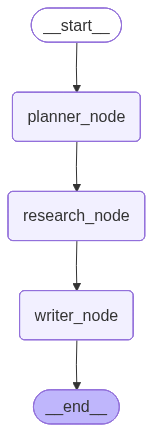

In [383]:
graph

In [ ]:
esult = graph.invoke({
    "item": {
        "day": 1,
        "title": "Introduction to Nutritious food",
        "concepts": [
            "neurons",
            "layers",
            "activation functions"
        ]
    },
    "research_summary": []
})



🔍 RESEARCHER NODE
📋 Total queries to run: 6
   1. neural network neuron example
   2. how neurons work in deep learning
   3. neural network layer example
   4. how layers work in neural networks
   5. activation function example
   6. types of activation functions in neural networks

🔎 Searching: 'neural network neuron example'
   ✅ Explain by Example: Deep Learning (NN)
      🔗 https://towardsdatascience.com/explain-by-example-deep-learning-nn-e15f5cfdab37/
      📝  at an airport recently – a statement I didn’t think I would be able to make for another year or so....
   ✅ Neural Network Regressor in Excel
      🔗 https://towardsdatascience.com/the-machine-learning-advent-calendar-day-17-neural-network-regressor-in-excel/
      📝  a neural network regressor with backpropagation in Excel

angela shi

Dec 17, 2025

7 min read Maki...

🔎 Searching: 'how neurons work in deep learning'
   ✅ How Do Neural Networks Work? Your 2026 Guide
      🔗 https://www.coursera.org/articles/how-do-neura

In [385]:
print(esult["draft"])

# The 3 Building Blocks Powering Every AI System
Every AI system you hear about — from ChatGPT to self-driving cars — runs on the same core idea: neural networks. But the strange part? These powerful systems are built from extremely simple mathematical units. Today we'll break down the three building blocks that make it all work. By understanding these basics, you'll gain a new appreciation for the complexity and beauty of artificial intelligence.

## Meet the Tiny Neurons Running the Show
Neurons are the fundamental units of a neural network — and they're surprisingly simple. You don't need a PhD to understand them. By the end of this section, you'll know exactly how they work. A **neuron** takes a set of numbers as input and multiplies each one by a learned **weight**. The weighted values are then summed together. This sum is passed through an **activation function** to produce a single output value.

A **neuron** is essentially a tiny math machine that takes inputs, performs a calcu

In [ ]:
result = graph.invoke({
    "item": {
        "day": 1,
        "title": "What You Eat Is What You Are",
        "concepts": [
            "Macronutrients",
            "Micronutrients",
            "Gut Health"
        ]
    },
    "plan": None,
    "research": [],
    "research_summary": [],
    "draft": "",
    "feedback": "",
    "revision_count": 0,
    "approved": False,
    "newsletter": ""
})


🔍 RESEARCHER NODE
📋 Total queries to run: 6
   1. macronutrient balance for athletes
   2. importance of protein for muscle growth
   3. vitamin D deficiency symptoms
   4. benefits of iron supplementation
   5. gut health and mental health connection
   6. prebiotic and probiotic supplements for gut health

🔎 Searching: 'macronutrient balance for athletes'
   ✅ Protein (nutrient) - Wikipedia
      🔗 https://en.wikipedia.org/wiki/Protein_(nutrient)
      📝  essential nutrients for the human body. They are one of the constituents of body tissue and also se...
   ✅ Acceptable Macronutrient Distribution Range - Wikipedia
      🔗 https://en.wikipedia.org/?title=Acceptable_Macronutrient_Distribution_Range&redirect=no
      📝  Acceptable Macronutrient Distribution Range - WikipediaJump to content  ...    # Acceptable Macronu...

🔎 Searching: 'importance of protein for muscle growth'
   ✅ Bodybuilding supplement
      🔗 https://en.wikipedia.org/wiki/Bodybuilding_supplement
      📝  supplemen

In [387]:
print(result["draft"])

# The Food Formula: How Your Diet Shapes Your Health
What if the key to unlocking your body's full potential lay in the foods you eat every day? The connection between your diet and overall health is more intricate than you think. Today, we'll break down the essential components that make up a healthy diet and how they impact your well-being. By understanding the role of different nutrients and their effects on the body, you can make informed decisions about your diet and maintain overall health.

## The Energy Providers: Carbs, Proteins, and Fats
Macronutrients are the foundation of a healthy diet, providing the body with energy, building blocks for growth and repair, and supporting various bodily functions. **Carbohydrates**, **proteins**, and **fats** are the three main types of macronutrients. Carbohydrates provide energy for your body, while proteins build and repair tissues. Fats are essential for brain function and hormone production.

Carbohydrates are the body's primary source